yes
doping =  0.17301273357519442 T =  0.16
time = 1.5641403198242188


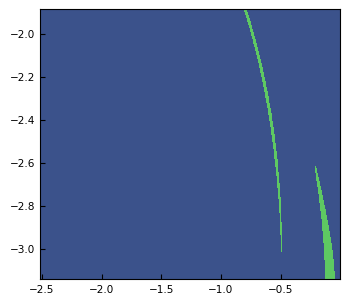

<Figure size 800x800 with 0 Axes>

In [165]:
#Fermi arc model density polt Fig1 PHYSICAL REVIEW LETTERS 133, 166501 (2024) Fermi surface
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import matplotlib.cm as cm
import time

plt.style.use("publication.mplstyle")
fig, axs = plt.subplots(1, figsize=(3.386, 2.093*1.4))

kB = 1.0
t = 1.0

t1 = -0.2
t2 = 0.1

Q = [np.pi, np.pi]

def band(kx, ky):
    return -2.0*t*(np.cos(kx) + np.cos(ky)) - 4.0*t1*np.cos(kx)*np.cos(ky) - 2*t2*(np.cos(2*kx) + np.cos(2*ky))

def band_Q(kx, ky):
    return -2.0*t*(np.cos(kx+Q[0]) + np.cos(ky+Q[1])) - 4.0*t1*np.cos(kx+Q[0])*np.cos(ky+Q[1]) - 2*t2*(np.cos(2*(kx+Q[0])) + np.cos(2*(ky+Q[1])))

def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    E_1 = -beta*epsilon_Q_minus_mu
    E_2 = -beta*(epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta*epsilon_minus_mu
    E_0 = np.full_like(E_1, 0)
    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])
    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = np.exp(E_0 - E_max) + np.exp(E_3 - E_max) + np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    return numerator/denominator

def average_occupation(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    return 2.0*np.sum(n_k) / N

def lorentzian(x, delta=0.005):
    return delta / (np.pi * (x * x + delta * delta))

def spectrum(kx, ky, omega, epsilon, epsilon_Q, mu, U, T):
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    spectrum = (1 - n_k)*lorentzian(omega - (band(kx, ky) - mu)) + n_k*lorentzian(omega - (band(kx, ky) - mu) - U)
    return spectrum

U = 0.4
T = 0.16
mu = -0.7828571428571429

Nk = 1000
kx_list = np.linspace(0.8*-np.pi, 0, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, -0.6*np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk
start_time = time.time()

spectrum_2d = np.full_like(KX, 0)
epsilon = band(KX, KY)
epsilon_Q = band_Q(KX, KY)
spectrum_2d = spectrum(KX, KY, 0, epsilon, epsilon_Q, mu, U, T)
        
fig = plt.figure(figsize=(8, 8))
threshold = 0.1 * np.max(spectrum_2d)
binary_spectrum = (spectrum_2d > threshold).astype(float)

axs.contourf(KX, KY, binary_spectrum, cmap="viridis", levels=[0, 0.5, 1])
plt.show

Nk = 400
kx_list = np.linspace(-np.pi, 0, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, 0, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

if np.any(binary_spectrum[0, :] == 1) or np.any(binary_spectrum[:, -1] == 1):
    print("yes")
    x = 1.0- average_occupation(mu, T, U, KX, KY, N)
    print('doping = ', x, 'T = ', T)
else:
    print('no')
    x = 1.0- average_occupation(mu, T, U, KX, KY, N)
    print('doping = ', x, 'T = ', T)

end_time = time.time()
print('time =', end_time - start_time)

-0.21162100000011574


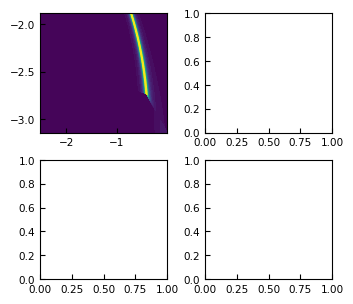

<Figure size 800x800 with 0 Axes>

In [151]:
#Fermi arc model density polt Fig1 PHYSICAL REVIEW LETTERS 133, 166501 (2024) Fermi surface
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import matplotlib.cm as cm
import time

plt.style.use("publication.mplstyle")
fig, axs = plt.subplots(2, 2, figsize=(3.386, 2.093*1.4))

kB = 1.0
t = 1.0

t1 = -0.2
t2 = 0.1

Q = [np.pi, np.pi]

def band(kx, ky):
    return -2.0*t*(np.cos(kx) + np.cos(ky)) - 4.0*t1*np.cos(kx)*np.cos(ky) - 2*t2*(np.cos(2*kx) + np.cos(2*ky))

def band_Q(kx, ky):
    return -2.0*t*(np.cos(kx+Q[0]) + np.cos(ky+Q[1])) - 4.0*t1*np.cos(kx+Q[0])*np.cos(ky+Q[1]) - 2*t2*(np.cos(2*(kx+Q[0])) + np.cos(2*(ky+Q[1])))

def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    E_1 = -beta*epsilon_Q_minus_mu
    E_2 = -beta*(epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta*epsilon_minus_mu
    E_0 = np.full_like(E_1, 0)
    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])
    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = np.exp(E_0 - E_max) + np.exp(E_3 - E_max) + np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    return numerator/denominator

def average_occupation(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    return 2.0*np.sum(n_k) / N

def lorentzian(x, delta=0.04):
    return delta / (np.pi * (x * x + delta * delta))

def spectrum(kx, ky, omega, epsilon, epsilon_Q, mu, U, T):
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    spectrum = (1 - n_k)*lorentzian(omega - (band(kx, ky) - mu)) + n_k*lorentzian(omega - (band(kx, ky) - mu) - U)
    return spectrum

U = 0.4
T = 0.0000
mu = -0.9457142857142857


Nk = 256
kx_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

spectrum_2d = np.full_like(KX, 0)
epsilon = band(KX, KY)
epsilon_Q = band_Q(KX, KY)
spectrum_2d = spectrum(KX, KY, 0, epsilon, epsilon_Q, mu, U, T)

fig = plt.figure(figsize=(8, 8))
N_levels = 40
#np.save(f'spectrum_K{Nk}_U={U}_mu={mu}', spectrum_2d)
axs[0, 0].contourf(KX, KY, spectrum_2d, cmap="viridis", levels=N_levels)
x = 1.0- average_occupation(mu, T, U, KX, KY, N)
print(x)

In [158]:
#Fermi arc model density polt Fig1 PHYSICAL REVIEW LETTERS 133, 166501 (2024) Fermi surface
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import matplotlib.cm as cm
import time

kB = 1.0
t = 1.0

t1 = -0.2
t2 = 0.1

Q = [np.pi, np.pi]

def band(kx, ky):
    return -2.0*t*(np.cos(kx) + np.cos(ky)) - 4.0*t1*np.cos(kx)*np.cos(ky) - 2*t2*(np.cos(2*kx) + np.cos(2*ky))

def band_Q(kx, ky):
    return -2.0*t*(np.cos(kx+Q[0]) + np.cos(ky+Q[1])) - 4.0*t1*np.cos(kx+Q[0])*np.cos(ky+Q[1]) - 2*t2*(np.cos(2*(kx+Q[0])) + np.cos(2*(ky+Q[1])))

def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    E_1 = -beta*epsilon_Q_minus_mu
    E_2 = -beta*(epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta*epsilon_minus_mu
    E_0 = np.full_like(E_1, 0)
    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])
    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = np.exp(E_0 - E_max) + np.exp(E_3 - E_max) + np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    return numerator/denominator

def average_occupation(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    return 2.0*np.sum(n_k) / N

def lorentzian(x, delta=0.005):
    return delta / (np.pi * (x * x + delta * delta))

def spectrum(kx, ky, omega, epsilon, epsilon_Q, mu, U, T):
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    spectrum = (1 - n_k)*lorentzian(omega - (band(kx, ky) - mu)) + n_k*lorentzian(omega - (band(kx, ky) - mu) - U)
    return spectrum

Nk = 1000
kx_list = np.linspace(0.8*-np.pi, 0, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, -0.6*np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

spectrum_2d = np.full_like(KX, 0)


T = 0.0

U = 1.0
N_mu_list_pseudo = 8
mu_list_pseudo = np.linspace(-1.19, -0.62, N_mu_list_pseudo)

#U = 0.4
#N_mu_list_pseudo = 4
#mu_list_pseudo = np.linspace(-1.19, -0.9457142857142857, N_mu_list_pseudo)



mu_result = []
T_result = []

start_time = time.time()

for k in range(0, len(mu_list_pseudo)):
    while True:
        mu = mu_list_pseudo[k]
        epsilon = band(KX, KY)
        epsilon_Q = band_Q(KX, KY)
        spectrum_2d = spectrum(KX, KY, 0, epsilon, epsilon_Q, mu, U, T)
        threshold = 0.1 * np.max(spectrum_2d)
        binary_spectrum = (spectrum_2d > threshold).astype(float)
        if np.any(binary_spectrum[0, :] == 1) or np.any(binary_spectrum[:, -1] == 1):
            mu_result.append(mu_list_pseudo[k])
            T_result.append(T)
            print('mu = ', mu, 'T = ', T)
            break   
        T = T + 0.01
        print(T)
        
end_time = time.time()
print(end_time-start_time)

Nk = 400
kx_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk
doping_result = []
for i in range(0, len(mu_result)):
    doping_result.append(1.0 - average_occupation(mu_result[i], T_result[i], U, KX, KY, N))

print(doping_result)
#np.save(f'pseudo_U={U}_T', T_result)
#np.save(f'pseudo_U={U}_doping', doping_result)
#np.save(f'pseudo_U={U}_mu', mu_result)

mu =  -1.19 T =  0.0
0.01
0.02
0.03
0.04
mu =  -1.1085714285714285 T =  0.04
0.05
0.060000000000000005
0.07
mu =  -1.0271428571428571 T =  0.07
0.08
0.09
0.09999999999999999
mu =  -0.9457142857142857 T =  0.09999999999999999
0.10999999999999999
0.11999999999999998
0.12999999999999998
0.13999999999999999
mu =  -0.8642857142857143 T =  0.13999999999999999
0.15
0.16
0.17
mu =  -0.7828571428571429 T =  0.17
0.18000000000000002
0.19000000000000003
0.20000000000000004
0.21000000000000005
mu =  -0.7014285714285714 T =  0.21000000000000005
0.22000000000000006
0.23000000000000007
0.24000000000000007
mu =  -0.62 T =  0.24000000000000007
40.199296951293945
[0.34312500000000057, 0.2971371028908967, 0.2629469121715158, 0.23460041645429042, 0.21167682284736067, 0.18975544501286268, 0.17116021416813254, 0.1523505880210798]


Text(-0.32, 1.05, '(a)')

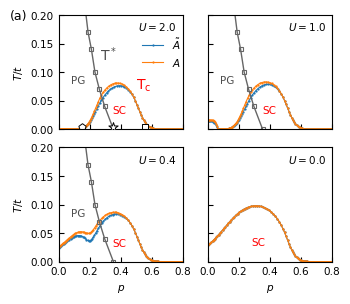

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import time
import matplotlib.pyplot as plt


plt.style.use("publication.mplstyle")
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(3.386, 2.093*1.4))
U = 2.0
g = 0.8

x_final11 = np.load(f'x_U={U}_g={g}.npy')
x_final11_0 = np.load(f'x0_U={U}_g={g}.npy')
Tc_final11 = np.load(f'Tc_U={U}_g={g}.npy')
Tc_final11_0 = np.load(f'Tc0_U={U}_g={g}.npy')
axs[0, 0].plot(x_final11, Tc_final11, 'o-', linewidth=0.8, markersize=0.8, label=r'$\tilde{A}$')
axs[0, 0].plot(x_final11_0, Tc_final11_0, 'o-', linewidth=0.8, markersize=0.8, label=r'$A$')
axs[0, 0].text(
    x=0.95,                     
    y=0.95,                     
    s=f'$U={U}$',               
    transform=axs[0, 0].transAxes, 
    horizontalalignment='right',  
    verticalalignment='top',      
)
axs[0, 0].legend(
    loc='upper left',
    bbox_to_anchor=(0.6, 0.9)
)
#axs[0, 0].legend(loc='upper left')

U = 1.0
g = 0.8
x_final14 = np.load(f'x_U={U}_g={g}.npy')
x_final14_0 = np.load(f'x0_U={U}_g={g}.npy')
Tc_final14 = np.load(f'Tc_U={U}_g={g}.npy')
Tc_final14_0 = np.load(f'Tc0_U={U}_g={g}.npy')
axs[0, 1].plot(x_final14, Tc_final14, 'o-', linewidth=0.8, markersize=0.8, label=f'A')
axs[0, 1].plot(x_final14_0, Tc_final14_0, 'o-', linewidth=0.8, markersize=0.8, label=r'$A_0$')
axs[0, 1].text(
    x=0.95,                     
    y=0.95,                     
    s=f'$U={U}$',               
    transform=axs[0, 1].transAxes, 
    horizontalalignment='right',  
    verticalalignment='top',      
)

U = 0.4
g = 0.8
x_final17 = np.load(f'x_U={U}_g={g}.npy')
x_final17_0 = np.load(f'x0_U={U}_g={g}.npy')
Tc_final17 = np.load(f'Tc_U={U}_g={g}.npy')
Tc_final17_0 = np.load(f'Tc0_U={U}_g={g}.npy')
axs[1, 0].plot(x_final17, Tc_final17, 'o-', linewidth=0.8, markersize=0.8, label=f'A')
axs[1, 0].plot(x_final17_0, Tc_final17_0, 'o-', linewidth=0.8, markersize=0.8, label=r'$A_0$')
axs[1, 0].text(
    x=0.95,                     
    y=0.95,                     
    s=f'$U={U}$',               
    transform=axs[1, 0].transAxes, 
    horizontalalignment='right',  
    verticalalignment='top',      
)

U = 0.0
g = 0.8
x_final20 = np.load(f'x_U={U}_g={g}.npy')
x_final20_0 = np.load(f'x0_U={U}_g={g}.npy')
Tc_final20 = np.load(f'Tc_U={U}_g={g}.npy')
Tc_final20_0 = np.load(f'Tc0_U={U}_g={g}.npy')
axs[1, 1].plot(x_final20, Tc_final20, 'o-', linewidth=0.8, markersize=0.8, label=f'A')
axs[1, 1].plot(x_final20_0, Tc_final20_0, 'o-', linewidth=0.8, markersize=0.8, label=r'$A_0$')
#axs[1, 1].set_title(f'$U={U}, g={g}$', loc='right')
axs[1, 1].text(
    x=0.95,                     
    y=0.95,                     
    s=f'$U={U}$',               
    transform=axs[1, 1].transAxes, 
    horizontalalignment='right',  
    verticalalignment='top',      
)
axs[1, 1].set_xlim(0, 0.8)
axs[1, 1].set_ylim(0, 0.2)

#axs[0, 0].scatter(0.1535385142149972, 0.001713534134609854, s=30, marker='p', color='tab:cyan', linewidths=0, zorder=2)
#axs[0, 0].scatter(0.1535385142149972, 0.003, s=30, marker='p', color='tab:cyan', linewidths=0, zorder=2)
#axs[0, 0].scatter(0.38645948958637044, 0.07605844333106182, s=30, marker='p', color='red', linewidths=0, zorder=2)

axs[0, 0].scatter(0.1535385142149972, 0.003, 
                  s=30,            # 增大点的大小，方便观察效果
                  marker='p',       # 五边形
                  facecolors='white',# 填充颜色
                  edgecolors='black',# 边框颜色
                  linewidths=0.7,     # 边框粗细，建议不要太大，否则会遮挡形状
                  zorder=2)
axs[0, 0].scatter(0.35, 0.003, 
                  s=50,            # 增大点的大小，方便观察效果
                  marker='*',       # 五边形
                  facecolors='white',# 填充颜色
                  edgecolors='black',# 边框颜色
                  linewidths=0.7,     # 边框粗细，建议不要太大，否则会遮挡形状
                  zorder=3)
axs[0, 0].scatter(0.56, 0.003, 
                  s=15,            # 增大点的大小，方便观察效果
                  marker='s',       # 五边形
                  facecolors='white',# 填充颜色
                  edgecolors='black',# 边框颜色
                  linewidths=0.7,     # 边框粗细，建议不要太大，否则会遮挡形状
                  zorder=2)
#axs[0, 0].scatter(0.36, 0.003, s=35, marker='p', color='black', linewidths=0, zorder=3, alpha = 0.8)

axs[1, 0].set_xlabel(r'$p$')
axs[1, 1].set_xlabel(r'$p$')
axs[0, 0].set_ylabel(r'$T/t$')
axs[1, 0].set_ylabel(r'$T/t$')
#axs[1, 1].legend()
#plt.show()

U = 2.0
T_result = np.load(f'pseudo_U={U}_T.npy')
doping_result = np.load(f'pseudo_U={U}_doping.npy')
axs[0, 0].plot(doping_result, T_result, '-', linewidth=1, markersize=2.5, marker='s', markerfacecolor='none',color='0.4')
axs[0, 0].text(0.27, 0.12, r'T$^*$', fontsize=10, color='0.3')
axs[0, 0].text(0.08, 0.08, r'PG', fontsize=7.5, color='0.3')
axs[0, 0].text(0.5, 0.07, r'T$_\text{c}$', fontsize=10, color='r')
axs[0, 0].text(0.35, 0.027, r'SC', fontsize=7.5, color='r')

U = 1.0
T_result = np.load(f'pseudo_U={U}_T.npy')
doping_result = np.load(f'pseudo_U={U}_doping.npy')
axs[0, 1].plot(doping_result, T_result, '-', linewidth=1, markersize=2.5, marker='s', markerfacecolor='none',color='0.4')
#axs[0, 0].text(0.27, 0.12, r'T$^*$', fontsize=10, color='0.3')
axs[0, 1].text(0.08, 0.08, r'PG', fontsize=7.5, color='0.3')
#axs[0, 0].text(0.5, 0.07, r'T$_\text{c}$', fontsize=10, color='r')
axs[0, 1].text(0.35, 0.027, r'SC', fontsize=7.5, color='r')

U = 1.0
T_result = np.load(f'pseudo_U={U}_T.npy')
doping_result = np.load(f'pseudo_U={U}_doping.npy')
axs[1, 0].plot(doping_result, T_result, '-', linewidth=1, markersize=2.5, marker='s', markerfacecolor='none',color='0.4')
#axs[0, 0].text(0.27, 0.12, r'T$^*$', fontsize=10, color='0.3')
axs[1, 0].text(0.08, 0.08, r'PG', fontsize=7.5, color='0.3')
#axs[0, 0].text(0.5, 0.07, r'T$_\text{c}$', fontsize=10, color='r')
axs[1, 0].text(0.35, 0.027, r'SC', fontsize=7.5, color='r')
axs[1, 1].text(0.28, 0.029, r'SC', fontsize=7.5, color='r')
axs[0, 0].set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])
axs[1, 0].set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])
axs[0, 1].set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])
axs[1, 1].set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])


# 在 axs[0, 0] 的左上角添加 (a)
axs[0, 0].text(-0.32, 1.05, '(a)', transform=axs[0,0].transAxes, 
        fontsize=9, va='top', ha='center')

#plt.savefig(f'U')


C:\Users\fishb\AppData\Local\Temp\ipykernel_8624\2188336428.py:18: RuntimeWarning: invalid value encountered in divide
  T_Udifference20 = (Tc_Ufinal20-Tc_Ufinal20_0)/Tc_Ufinal20
C:\Users\fishb\AppData\Local\Temp\ipykernel_8624\2188336428.py:29: RuntimeWarning: invalid value encountered in divide
  T_Udifference15 = (Tc_Ufinal15-Tc_Ufinal15_0)/Tc_Ufinal15
C:\Users\fishb\AppData\Local\Temp\ipykernel_8624\2188336428.py:39: RuntimeWarning: invalid value encountered in divide
  T_Udifference11 = (Tc_Ufinal11-Tc_Ufinal11_0)/Tc_Ufinal11
C:\Users\fishb\AppData\Local\Temp\ipykernel_8624\2188336428.py:51: RuntimeWarning: invalid value encountered in divide
  T_Udifference11 = (Tc_Ufinal11-Tc_Ufinal11_0)/Tc_Ufinal11


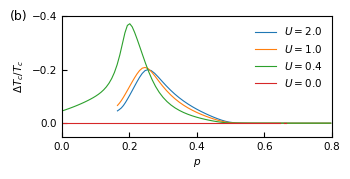

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import time

plt.figure(figsize=(3.386, 2.093*0.8))
import matplotlib.pyplot as plt
plt.style.use("publication.mplstyle")

U = 2.0
g = 0.8
x_Ufinal20 = np.load(f'x_U={U}_g={g}.npy')
x_Ufinal20_0 = np.load(f'x0_U={U}_g={g}.npy')
Tc_Ufinal20 = np.load(f'Tc_U={U}_g={g}.npy')
Tc_Ufinal20_0 = np.load(f'Tc0_U={U}_g={g}.npy')

T_Udifference20 = (Tc_Ufinal20-Tc_Ufinal20_0)/Tc_Ufinal20
T_Udifference20_fix = np.nan_to_num(T_Udifference20, nan =0)
plt.plot(x_Ufinal20[x_Ufinal20 >= 0.16], T_Udifference20_fix[x_Ufinal20 >= 0.16], label=f'$U={U}$')

U = 1.0
g = 0.8
x_Ufinal15 = np.load(f'x_U={U}_g={g}.npy')
x_Ufinal15_0 = np.load(f'x0_U={U}_g={g}.npy')
Tc_Ufinal15 = np.load(f'Tc_U={U}_g={g}.npy')
Tc_Ufinal15_0 = np.load(f'Tc0_U={U}_g={g}.npy')

T_Udifference15 = (Tc_Ufinal15-Tc_Ufinal15_0)/Tc_Ufinal15
T_Udifference15_fix = np.nan_to_num(T_Udifference15, nan =0)
plt.plot(x_Ufinal15[x_Ufinal15 >= 0.16], T_Udifference15_fix[x_Ufinal15 >= 0.16], label=f'$U={U}$')

U = 0.4
g = 0.8
x_Ufinal11 = np.load(f'x_U={U}_g={g}.npy')
x_Ufinal11_0 = np.load(f'x0_U={U}_g={g}.npy')
Tc_Ufinal11 = np.load(f'Tc_U={U}_g={g}.npy')
Tc_Ufinal11_0 = np.load(f'Tc0_U={U}_g={g}.npy')
T_Udifference11 = (Tc_Ufinal11-Tc_Ufinal11_0)/Tc_Ufinal11
T_Udifference11_fix = np.nan_to_num(T_Udifference11, nan =0)
plt.plot(x_Ufinal11[x_Ufinal11 >= 0.0], T_Udifference11_fix[x_Ufinal11 >= 0.0], label=f'$U={U}$')


U = 0.0
g = 0.8

x_Ufinal11 = np.load(f'x_U={U}_g={g}.npy')
x_Ufinal11_0 = np.load(f'x0_U={U}_g={g}.npy')
Tc_Ufinal11 = np.load(f'Tc_U={U}_g={g}.npy')
Tc_Ufinal11_0 = np.load(f'Tc0_U={U}_g={g}.npy')
T_Udifference11 = (Tc_Ufinal11-Tc_Ufinal11_0)/Tc_Ufinal11
plt.plot(x_Ufinal11[x_Ufinal11 >= 0.0], T_Udifference11[x_Ufinal11 >= 0.0], label=f'$U={U}$')

plt.legend()
plt.xlim(0, 0.8)
plt.ylim(0.05,-0.4)
plt.xlabel(r'$p$')
plt.ylabel(r'$\Delta T_c/T_c$')
plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8])
plt.yticks([0.0, -0.2, -0.4])

ax = plt.gca()
# transform=ax.transAxes 确保坐标 (0,1) 永远指向左上角
ax.text(-0.16, 1.05, '(b)', transform=ax.transAxes, 
        fontsize=9, va='top', ha='center')
#plt.savefig(f'U_difference')
plt.show()